In [ ]:
# ! pip install pytorchvideo transformers evaluate -q
# ! pip install pytorchvideo torchvision==0.12.0
# ! pip install evaluate

In [2]:
# pip install opencv-python


In [ ]:
# ! pip install --upgrade torch

In [1]:
#model_ckpt = "MCG-NJU/videomae-base" # pre-trained model from which to fine-tune
#model_ckpt = "google/vivit-b-16x2-kinetics400"
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"

batch_size = 4 # batch size for training and evaluation
from transformers import VideoMAEConfig, VideoMAEModel

# Initializing a VideoMAE videomae-base style configuration
configuration = VideoMAEConfig()

# Randomly initializing a model from the configuration
model = VideoMAEModel(configuration)

# Accessing the model configuration
configuration = model.config
print(configuration)

/media/cse/HDD/Shawon/shawon/shawon_env/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /media/cse/HDD/Shawon/shawon/shawon_env/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warn(f"Failed to load image Python extension: {e}")


VideoMAEConfig {
  "_attn_implementation_autoset": true,
  "attention_probs_dropout_prob": 0.0,
  "decoder_hidden_size": 384,
  "decoder_intermediate_size": 1536,
  "decoder_num_attention_heads": 6,
  "decoder_num_hidden_layers": 4,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "videomae",
  "norm_pix_loss": true,
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_frames": 16,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.46.1",
  "tubelet_size": 2,
  "use_mean_pooling": true
}



In [ ]:
# model_ckpt="facebook/timesformer-base-finetuned-k400"
# #model_ckpt = "MCG-NJU/videomae-base" # pre-trained model from which to fine-tune
# #model_ckpt = "google/vivit-b-16x2-kinetics400"
# batch_size = 4 # batch size for training and evaluation
# from transformers import TimesformerConfig, TimesformerModel

# # Initializing a TimeSformer timesformer-base style configuration
# configuration = TimesformerConfig()

# # Initializing a model from the configuration
# model = TimesformerModel(configuration)

# # Accessing the model configuration
# configuration = model.config
# print(configuration)


In [1]:
model_ckpt = "google/vivit-b-16x2-kinetics400"
batch_size = 4
from transformers import VivitConfig, VivitModel

# Initializing a ViViT google/vivit-b-16x2-kinetics400 style configuration
configuration = VivitConfig()

# Initializing a model (with random weights) from the google/vivit-b-16x2-kinetics400 style configuration
model = VivitModel(configuration)

# Accessing the model configuration
configuration = model.config

print(configuration)

/media/cse/HDD/Shawon/shawon/shawon_env/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /media/cse/HDD/Shawon/shawon/shawon_env/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warn(f"Failed to load image Python extension: {e}")


VivitConfig {
  "_attn_implementation_autoset": true,
  "attention_probs_dropout_prob": 0.0,
  "hidden_act": "gelu_fast",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-06,
  "model_type": "vivit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_frames": 32,
  "num_hidden_layers": 12,
  "qkv_bias": true,
  "transformers_version": "4.46.1",
  "tubelet_size": [
    2,
    16,
    16
  ]
}



In [2]:
import pathlib

# Specify the dataset root path (make sure to define it beforehand)
#dataset_root_path = pathlib.Path('/kaggle/input/bdslw60-all-u1-u4-and-u8/BdSLW60_ALL')  # Change to your actual path
#output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/Val(U5)_Test(U4,U8)_Framerate corrected')
#output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/wlasl_100_class')
output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/WLASL Dataset')
# Count videos in each set
video_count_train = len(list(output_root_path.glob("train/*/*.mp4")))
video_count_val = len(list(output_root_path.glob("val/*/*.mp4")))
video_count_test = len(list(output_root_path.glob("test/*/*.mp4")))

# Calculate total videos
video_total = video_count_train + video_count_val + video_count_test
print(f"Total videos: {video_total}")

# List all video file paths
all_video_file_paths = (
    list(output_root_path.glob("train/*/*.mp4")) +
    list(output_root_path.glob("val/*/*.mp4")) +
    list(output_root_path.glob("test/*/*.mp4"))
)

# Display the first five video file paths
print(all_video_file_paths[:5])

# Print total number of videos in each set and the first 5 video file paths for training
print(f"Total videos: {video_total}")
print(f"Training videos: {video_count_train}, Validation videos: {video_count_val}, Test videos: {video_count_test}")


Total videos: 21083
[PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/WLASL Dataset/train/canoe/08980.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/WLASL Dataset/train/canoe/08984.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/WLASL Dataset/train/canoe/08979.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/WLASL Dataset/train/canoe/08985.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/WLASL Dataset/train/canoe/67472.mp4')]
Total videos: 21083
Training videos: 14289, Validation videos: 3916, Test videos: 2878


In [3]:
# Adjust class label extraction logic
class_labels = sorted({str(path.parent.name) for path in all_video_file_paths})  # Use parent folder name as class label
label2id = {label: i for i, label in enumerate(class_labels)}
id2label = {i: label for label, i in label2id.items()}
# Print the unique class labels and their mappings
print(f"Unique classes: {list(label2id.keys())}.")
print(f"Label to ID mapping: {label2id}")
#print(f"ID to Label mapping: {id2label}")

Unique classes: ['a', 'a lot', 'abdomen', 'able', 'about', 'above', 'accent', 'accept', 'accident', 'accomplish', 'accountant', 'across', 'act', 'action', 'active', 'activity', 'actor', 'adapt', 'add', 'address', 'adjective', 'adjust', 'admire', 'admit', 'adopt', 'adult', 'advanced', 'advantage', 'adverb', 'affect', 'afraid', 'africa', 'after', 'afternoon', 'again', 'against', 'age', 'agenda', 'ago', 'agree', 'agreement', 'ahead', 'aid', 'aim', 'airplane', 'alarm', 'alcohol', 'algebra', 'all', 'all day', 'allergy', 'alligator', 'allow', 'almost', 'alone', 'alphabet', 'already', 'also', 'always', 'amazing', 'america', 'amputate', 'analyze', 'anatomy', 'and', 'angel', 'angle', 'angry', 'animal', 'anniversary', 'announce', 'annoy', 'another', 'answer', 'any', 'anyway', 'apart', 'apartment', 'apostrophe', 'appear', 'appetite', 'apple', 'appointment', 'appreciate', 'approach', 'appropriate', 'approve', 'april', 'archery', 'area', 'argue', 'arizona', 'arm', 'army', 'around', 'arrest', 'arriv

In [4]:
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from transformers import VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification

# image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")
# model = VivitForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
# )

# image_processor = AutoImageProcessor.from_pretrained(model_ckpt)
# model = TimesformerForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,
# )

image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)
import pytorchvideo.data

from pytorchvideo.transforms import (
    ApplyTransformToKey,
    Normalize,
    RandomShortSideScale,
    RemoveKey,
    ShortSideScale,
    UniformTemporalSubsample,
)

from torchvision.transforms import (
    Compose,
    Lambda,
    RandomCrop,
    RandomHorizontalFlip,
    Resize,
)

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base-finetuned-kinetics and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([2000]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([2000, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
import os
import os
import cv2  # Import OpenCV to handle video files
from pytorchvideo.data import make_clip_sampler, Ucf101
from torchvision.transforms import Compose
from transformers import VideoMAEForVideoClassification, VideoMAEConfig
from transformers import VivitConfig, VivitModel, VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification


# Load the model configuration
#model_ckpt = "MCG-NJU/videomae-base"
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
#model_ckpt = "facebook/timesformer-base-finetuned-k400"
#config = TimesformerForVideoClassification.from_pretrained(model_ckpt)
config = VideoMAEConfig.from_pretrained(model_ckpt)
# model_ckpt = "google/vivit-b-16x2-kinetics400"
# config = VivitForVideoClassification.from_pretrained(model_ckpt)
#num_frames_to_sample = config.num_frames


mean = image_processor.image_mean
std = image_processor.image_std
if "shortest_edge" in image_processor.size:
    height = width = image_processor.size["shortest_edge"]
else:
    height = image_processor.size["height"]
    width = image_processor.size["width"]
resize_to = (height, width)

num_frames_to_sample = model.config.num_frames
print(f"Number of frames to sample: {num_frames_to_sample}")
sample_rate = 8 # 5.2s
fps = 25
clip_duration = num_frames_to_sample * sample_rate / fps

# Training dataset transformations.
train_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                    RandomShortSideScale(min_size=256, max_size=320),
                    RandomCrop(resize_to),
                    RandomHorizontalFlip(p=0.5),
                    
                ]
            ),
        ),
    ]
)

# Training dataset.
train_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "train"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("random", clip_duration),
    decode_audio=False,
    transform=train_transform,
)



# Validation and evaluation datasets' transformations.
val_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                ]
            ),
        ),
    ]
)

# Validation and evaluation datasets.
val_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "val"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

test_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "test"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

Number of frames to sample: 16


In [6]:
train_dataset.num_videos, val_dataset.num_videos, test_dataset.num_videos

(14289, 3916, 2878)

In [ ]:
#! pip list

In [7]:
# train data sample
sample_video = next(iter(train_dataset))
sample_video.keys()

dict_keys(['video', 'video_name', 'video_index', 'clip_index', 'aug_index', 'label'])

In [8]:
def investigate_video(sample_video):
    """Utility to investigate the keys present in a single video sample."""
    for k in sample_video:
        if k == "video":
            print(k, sample_video["video"].shape)
        else:
            print(k, sample_video[k])

    print(f"Video label: {id2label[sample_video[k]]}")

investigate_video(sample_video)

video torch.Size([3, 16, 224, 224])
video_name 49603.mp4
video_index 10722
clip_index 0
aug_index 0
label 1509
Video label: school


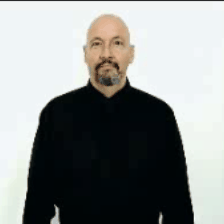

In [9]:
import imageio
import numpy as np
from IPython.display import Image


def unnormalize_img(img):
    """Un-normalizes the image pixels."""
    img = (img * std) + mean
    img = (img * 255).astype("uint8")
    return img.clip(0, 255)


def create_gif(video_tensor, filename="sample.gif"):
    """Prepares a GIF from a video tensor.
    
    The video tensor is expected to have the following shape:
    (num_frames, num_channels, height, width).
    """
    frames = []
    for video_frame in video_tensor:
        frame_unnormalized = unnormalize_img(video_frame.permute(1, 2, 0).numpy())
        frames.append(frame_unnormalized)
    kargs = {"duration": 0.25}
    imageio.mimsave(filename, frames, "GIF", **kargs)
    return filename


def display_gif(video_tensor, gif_name="sample.gif"):
    """Prepares and displays a GIF from a video tensor."""
    video_tensor = video_tensor.permute(1, 0, 2, 3)
    gif_filename = create_gif(video_tensor, gif_name)
    return Image(filename=gif_filename)

video_tensor = sample_video["video"]
display_gif(video_tensor)
#print(video_tensor.shape)

In [10]:
import evaluate
metric = evaluate.load("accuracy")
import torch

def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions."""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)


def collate_fn(examples):
    """The collation function to be used by `Trainer` to prepare data batches."""
    # permute to (num_frames, num_channels, height, width)
    pixel_values = torch.stack(
        [example["video"].permute(1, 0, 2, 3) for example in examples]
    )
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
from huggingface_hub import login, hf_hub_download
# RnW token

# Authenticate using the API token
login(token=hf_token)

# WLASL 2000 200 epoch -- VideoMAE kinetics

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base-finetuned-kinetics and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([2000]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([2000, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/media/cse/HDD/Shawon/shawon/shawon_env/lib/python3.10/site-packages/transformers/training_args.py:1559: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_3765953/3007239726.py:182: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Tra

  0%|          | 0/357200 [00:00<?, ?it/s]

{'loss': 30.4518, 'grad_norm': 20.226421356201172, 'learning_rate': 1.3997760358342666e-07, 'epoch': 0.0}
{'loss': 30.4528, 'grad_norm': 24.225967407226562, 'learning_rate': 2.799552071668533e-07, 'epoch': 0.0}
{'loss': 30.5309, 'grad_norm': 20.26617431640625, 'learning_rate': 4.1993281075028e-07, 'epoch': 0.0}
{'loss': 30.4432, 'grad_norm': 18.84654426574707, 'learning_rate': 5.599104143337066e-07, 'epoch': 0.0}
{'loss': 30.476, 'grad_norm': 19.313968658447266, 'learning_rate': 6.998880179171333e-07, 'epoch': 0.0}
{'loss': 30.4617, 'grad_norm': 19.507740020751953, 'learning_rate': 8.3986562150056e-07, 'epoch': 0.0}
{'loss': 30.4795, 'grad_norm': 18.0329647064209, 'learning_rate': 9.798432250839866e-07, 'epoch': 0.0}
{'loss': 30.4514, 'grad_norm': 17.514469146728516, 'learning_rate': 1.1198208286674133e-06, 'epoch': 0.0}
{'loss': 30.4258, 'grad_norm': 18.40747833251953, 'learning_rate': 1.25979843225084e-06, 'epoch': 0.0}
{'loss': 30.4209, 'grad_norm': 15.273112297058105, 'learning_rat

2025-01-24 23:38:21,950 - INFO - Metrics: Top-1: 0.0013, Top-5: 0.0041, Top-10: 0.0077, Accuracy: 0.0013, Precision: 0.0004, Recall: 0.0013, F1: 0.0003


{'eval_loss': 7.599897861480713, 'eval_top_1_accuracy': 0.0012768130745658835, 'eval_top_5_accuracy': 0.0040858018386108275, 'eval_top_10_accuracy': 0.007660878447395302, 'eval_accuracy': 0.0012768130745658835, 'eval_precision': 0.0003945151684672421, 'eval_recall': 0.0012768130745658835, 'eval_f1': 0.0003286915125900798, 'eval_runtime': 160.9217, 'eval_samples_per_second': 24.335, 'eval_steps_per_second': 12.167, 'epoch': 0.01}
{'loss': 30.4173, 'grad_norm': 11.807793617248535, 'learning_rate': 2.5181970884658456e-06, 'epoch': 1.0}
{'loss': 30.3847, 'grad_norm': 12.485947608947754, 'learning_rate': 2.6581746920492722e-06, 'epoch': 1.0}
{'loss': 30.3864, 'grad_norm': 12.61637020111084, 'learning_rate': 2.798152295632699e-06, 'epoch': 1.0}
{'loss': 30.3646, 'grad_norm': 14.853839874267578, 'learning_rate': 2.9381298992161256e-06, 'epoch': 1.0}
{'loss': 30.3906, 'grad_norm': 13.900428771972656, 'learning_rate': 3.0781075027995522e-06, 'epoch': 1.0}
{'loss': 30.38, 'grad_norm': 15.1404209

...

2025-01-25 07:44:52,611 - INFO - Metrics: Top-1: 0.3687, Top-5: 0.6969, Top-10: 0.7855, Accuracy: 0.3687, Precision: 0.3434, Recall: 0.3687, F1: 0.3312


{'eval_loss': 3.318777322769165, 'eval_top_1_accuracy': 0.3687436159346272, 'eval_top_5_accuracy': 0.6968845760980592, 'eval_top_10_accuracy': 0.7854954034729316, 'eval_accuracy': 0.3687436159346272, 'eval_precision': 0.3433794202052629, 'eval_recall': 0.3687436159346272, 'eval_f1': 0.33117920128900724, 'eval_runtime': 115.7117, 'eval_samples_per_second': 33.843, 'eval_steps_per_second': 16.921, 'epoch': 34.0}
{'loss': 0.6981, 'grad_norm': 17.592552185058594, 'learning_rate': 4.582369043175314e-05, 'epoch': 35.0}
{'loss': 0.5374, 'grad_norm': 34.496055603027344, 'learning_rate': 4.580813736468832e-05, 'epoch': 35.0}
{'loss': 0.7976, 'grad_norm': 48.30421829223633, 'learning_rate': 4.5792584297623494e-05, 'epoch': 35.0}
{'loss': 0.6289, 'grad_norm': 36.826202392578125, 'learning_rate': 4.577703123055867e-05, 'epoch': 35.0}
{'loss': 0.7489, 'grad_norm': 31.521106719970703, 'learning_rate': 4.5761478163493844e-05, 'epoch': 35.0}
{'loss': 0.6528, 'grad_norm': 0.38109827041625977, 'learning

2025-01-25 07:59:12,696 - INFO - Metrics: Top-1: 0.3721, Top-5: 0.6987, Top-10: 0.7911, Accuracy: 0.3718, Precision: 0.3566, Recall: 0.3718, F1: 0.3366


{'eval_loss': 3.3163700103759766, 'eval_top_1_accuracy': 0.37206332992849844, 'eval_top_5_accuracy': 0.6986721144024515, 'eval_top_10_accuracy': 0.7911133810010215, 'eval_accuracy': 0.3718079673135853, 'eval_precision': 0.35664473422389664, 'eval_recall': 0.3718079673135853, 'eval_f1': 0.33662947681078426, 'eval_runtime': 118.3976, 'eval_samples_per_second': 33.075, 'eval_steps_per_second': 16.538, 'epoch': 35.01}
{'train_runtime': 31106.056, 'train_samples_per_second': 91.866, 'train_steps_per_second': 11.483, 'train_loss': 9.042802423402353, 'epoch': 35.01}


2025-01-25 08:07:53,614 - INFO - Metrics: Top-1: 0.9157, Top-5: 0.9975, Top-10: 0.9994, Accuracy: 0.9156, Precision: 0.9298, Recall: 0.9156, F1: 0.9115
2025-01-25 08:07:54,718 - INFO - Training Metrics - Top-1: 0.9157, Top-5: 0.9975, Top-10: 0.9994, Accuracy: 0.9156, Precision: 0.9298, Recall: 0.9156, F1: 0.9115


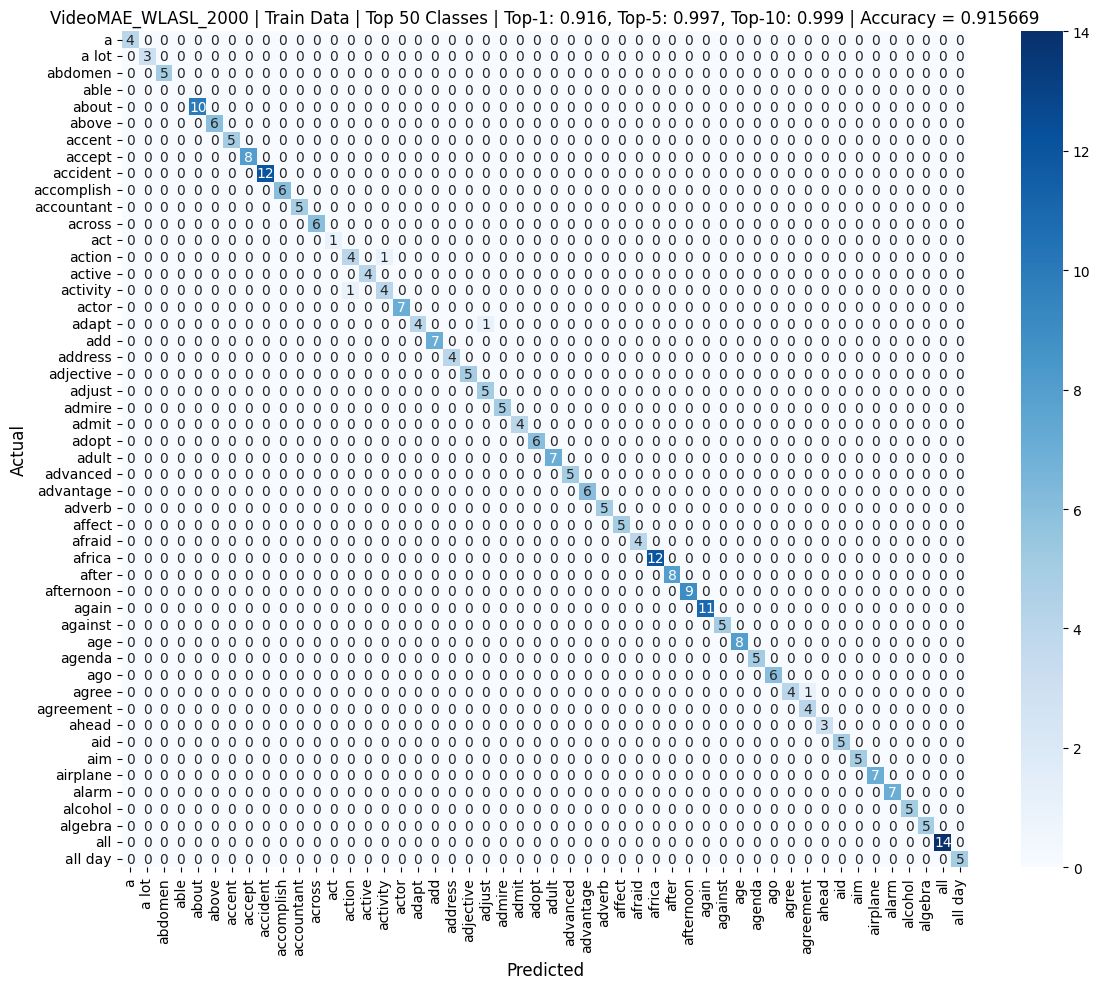

2025-01-25 08:09:52,149 - INFO - Metrics: Top-1: 0.3925, Top-5: 0.7360, Top-10: 0.8207, Accuracy: 0.3927, Precision: 0.3493, Recall: 0.3927, F1: 0.3457
2025-01-25 08:09:52,454 - INFO - Validation Metrics - Top-1: 0.3925, Top-5: 0.7360, Top-10: 0.8207, Accuracy: 0.3927, Precision: 0.3493, Recall: 0.3927, F1: 0.3457


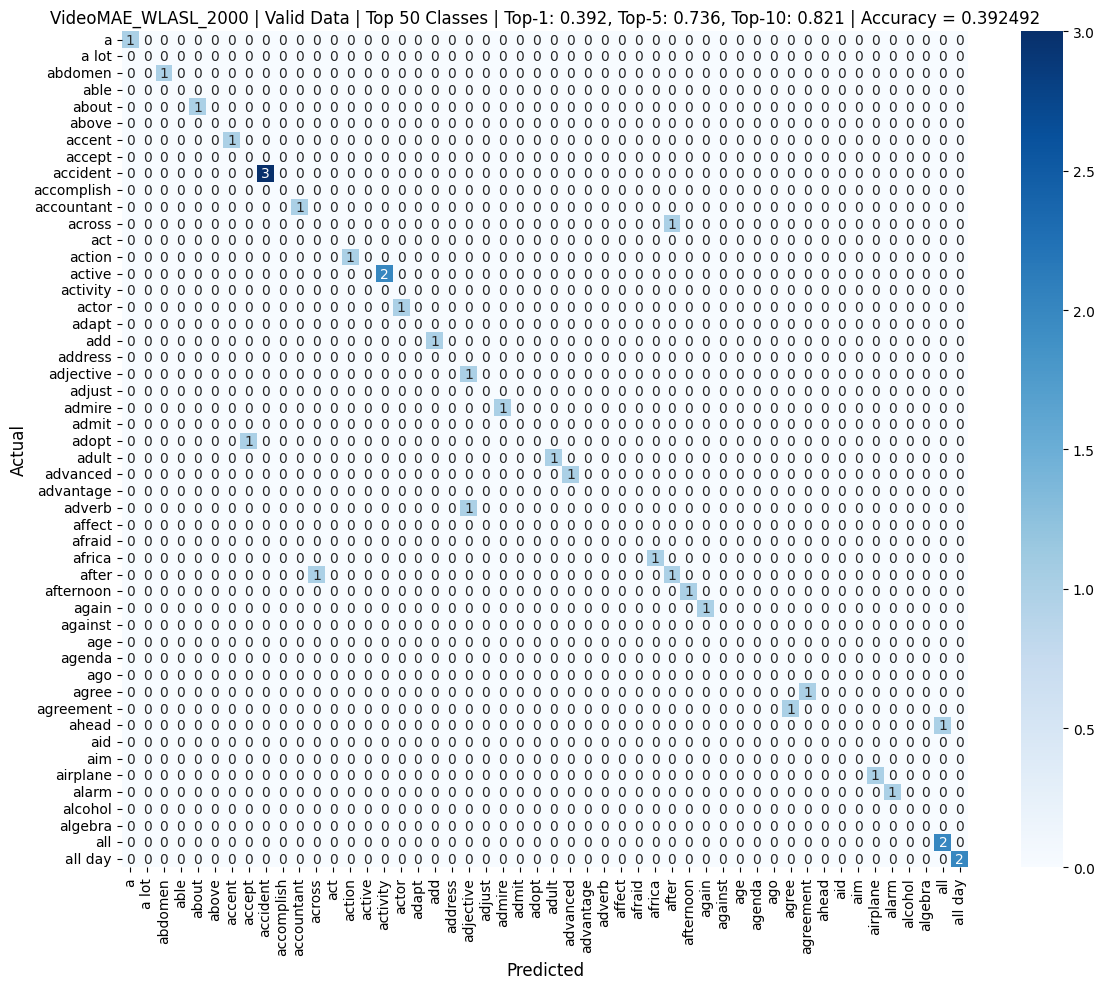

2025-01-25 08:11:52,863 - INFO - Metrics: Top-1: 0.0688, Top-5: 0.1240, Top-10: 0.1449, Accuracy: 0.0688, Precision: 0.0586, Recall: 0.0688, F1: 0.0592
2025-01-25 08:11:53,086 - INFO - Test Metrics - Top-1: 0.0688, Top-5: 0.1240, Top-10: 0.1449, Accuracy: 0.0688, Precision: 0.0586, Recall: 0.0688, F1: 0.0592


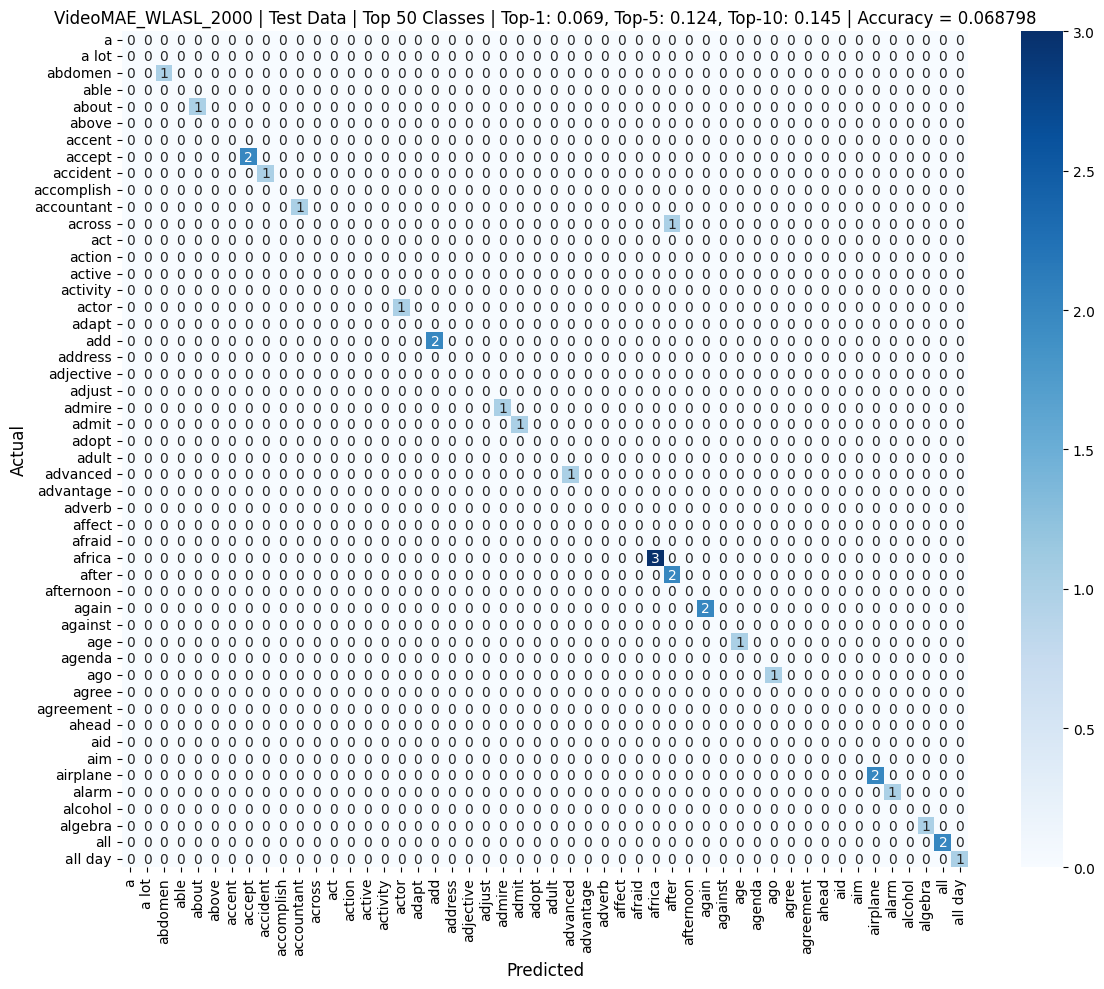

***** test metrics *****
  accuracy        = 0.0688
  f1              = 0.0592
  precision       = 0.0586
  recall          = 0.0688
  top_10_accuracy = 0.1449
  top_1_accuracy  = 0.0688
  top_5_accuracy  =  0.124


2025-01-25 08:12:03,084 - INFO - Training complete. Model and checkpoints saved in: /media/cse/HDD/Shawon/shawon/MY DATA/VideoMAE_WLASL_2000_200_epochs_p20_SR_8_kinetics


Training complete. Model and checkpoints saved in: /media/cse/HDD/Shawon/shawon/MY DATA/VideoMAE_WLASL_2000_200_epochs_p20_SR_8_kinetics


In [13]:
import os
import torch
import logging
import matplotlib.pyplot as plt
import numpy as np
from transformers import Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
from transformers import EarlyStoppingCallback, AutoImageProcessor, VideoMAEForVideoClassification, VideoMAEImageProcessor
import seaborn as sns
import evaluate

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

num_epochs = 200

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model and image processor
#model_ckpt = "MCG-NJU/videomae-base"
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)
# model_ckpt = "google/vivit-b-16x2-kinetics400"
# image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")  
# model = VivitForVideoClassification.from_pretrained(
# model_ckpt,
# label2id=label2id,
# id2label=id2label,
# ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
# ) 
# model_ckpt="facebook/timesformer-base-finetuned-k400"
# image_processor = AutoImageProcessor.from_pretrained("facebook/timesformer-base-finetuned-k400")
# model = TimesformerForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,)

model.to(device)

# Output directory for checkpoints
output_checkpoint_dir = r"/media/cse/HDD/Shawon/shawon/MY DATA/VideoMAE_WLASL_2000_200_epochs_p20_SR_8_kinetics"
os.makedirs(output_checkpoint_dir, exist_ok=True)

# Plot confusion matrix
# def plot_confusion_matrix(conf_matrix, class_labels, accuracy=None, dataset_name="Test Data", normalize=False, filename="confusion_matrix.png"):
#     if normalize:
#         conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

#     plt.figure(figsize=(12, 10))
#     sns.heatmap(conf_matrix, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", 
#                 xticklabels=class_labels, yticklabels=class_labels)
    
#     plt.xticks(rotation=90)
#     plt.yticks(rotation=0)
    
#     plt.xlabel("Predicted", fontsize=12)
#     plt.ylabel("Actual", fontsize=12)
    
#     title = f"VideoMAE_WLASL | {dataset_name} | Accuracy = {accuracy:.6f}" if accuracy is not None else f"VideoMAE_WLASL | {dataset_name}"
#     plt.title(title)
    
#     plt.tight_layout()
#     plt.savefig(filename)
#     plt.show()
#     plt.close()

def plot_confusion_matrix(conf_matrix, class_labels, accuracy=None, dataset_name="Test Data", normalize=False, filename="confusion_matrix.png", subset_size=None):
    """
    Plots a confusion matrix for a subset of classes or the full matrix.

    Args:
        conf_matrix: numpy.ndarray, the confusion matrix.
        class_labels: list, the labels of the classes.
        accuracy: float, overall accuracy (optional).
        dataset_name: str, name of the dataset (optional).
        normalize: bool, whether to normalize the matrix.
        filename: str, file name for saving the plot.
        subset_size: int, number of classes to visualize (None for full matrix).
    """
    # Subset the confusion matrix and labels if subset_size is specified
    if subset_size:
        conf_matrix = conf_matrix[:subset_size, :subset_size]
        class_labels = class_labels[:subset_size]
    
    if normalize:
        conf_matrix = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(conf_matrix, annot=True, fmt=".2f" if normalize else "d", cmap="Blues", 
                xticklabels=class_labels, yticklabels=class_labels)
    
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("Actual", fontsize=12)
    
    title = f"VideoMAE_WLASL_2000 | {dataset_name} | Accuracy = {accuracy:.6f}" if accuracy is not None else f"VideoMAE_WLASL_2000| {dataset_name}"
    plt.title(title)
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()
    plt.close()




# Helper function to calculate Top-k accuracy
def top_k_accuracy(predictions, labels, k):
    """Compute the Top-k accuracy."""
    top_k_preds = np.argsort(predictions, axis=1)[:, -k:]  # Get top k predictions
    correct = np.any(top_k_preds == labels[:, None], axis=1)  # Check if true label is in top k
    return np.mean(correct)

# Updated compute_metrics function
def compute_metrics(p):
    preds = p.predictions
    labels = p.label_ids
    
    # Top-k Accuracy Metrics
    top_1 = top_k_accuracy(preds, labels, k=1)
    top_5 = top_k_accuracy(preds, labels, k=5)
    top_10 = top_k_accuracy(preds, labels, k=10)
    
    # Argmax predictions for precision/recall/F1
    preds_argmax = np.argmax(preds, axis=1)
    
    # Calculate precision, recall, and F1 score
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds_argmax, average='weighted', zero_division=0
    )
    accuracy = accuracy_score(labels, preds_argmax)
    
    # Log metrics
    logging.info(
        f"Metrics: Top-1: {top_1:.4f}, Top-5: {top_5:.4f}, Top-10: {top_10:.4f}, "
        f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}"
    )
    
    return {
        "top_1_accuracy": top_1,
        "top_5_accuracy": top_5,
        "top_10_accuracy": top_10,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Training arguments
#batch_size = 32
args = TrainingArguments(
    output_dir=output_checkpoint_dir,
    remove_unused_columns=False,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_ratio=0.1,
    logging_steps=100,
    metric_for_best_model="accuracy",
    push_to_hub=True,
    load_best_model_at_end=True,
    max_steps=(train_dataset.num_videos // (2*4)) * num_epochs,  # Dynamically calculate max_steps
    report_to="none",
    fp16=True,
    weight_decay=0.01,
)

# Trainer initialization
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=20)],
)

# Train the model
trainer.train()
trainer.save_model()

# ------------------- TRAINING METRICS -------------------
train_predictions = trainer.predict(train_dataset)
train_preds = train_predictions.predictions
train_labels = train_predictions.label_ids

train_top_1 = top_k_accuracy(train_preds, train_labels, k=1)
train_top_5 = top_k_accuracy(train_preds, train_labels, k=5)
train_top_10 = top_k_accuracy(train_preds, train_labels, k=10)

train_preds_argmax = np.argmax(train_preds, axis=1)
train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
    train_labels, train_preds_argmax, average='weighted', zero_division=0
)
train_accuracy = accuracy_score(train_labels, train_preds_argmax)

logging.info(
    f"Training Metrics - Top-1: {train_top_1:.4f}, Top-5: {train_top_5:.4f}, Top-10: {train_top_10:.4f}, "
    f"Accuracy: {train_accuracy:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}"
)

plot_confusion_matrix(
    conf_matrix=confusion_matrix(train_labels, train_preds_argmax),
    class_labels=list(id2label.values()),
    accuracy=train_top_1,
    dataset_name=f"Train Data | Top 50 Classes | Top-1: {train_top_1:.3f}, Top-5: {train_top_5:.3f}, Top-10: {train_top_10:.3f}",
    filename="confusion_matrix_train600.png",
    subset_size=50  # Visualize only the first 50 classes
)

# ------------------- VALIDATION METRICS -------------------
val_predictions = trainer.predict(val_dataset)
val_preds = val_predictions.predictions
val_labels = val_predictions.label_ids

val_top_1 = top_k_accuracy(val_preds, val_labels, k=1)
val_top_5 = top_k_accuracy(val_preds, val_labels, k=5)
val_top_10 = top_k_accuracy(val_preds, val_labels, k=10)

val_preds_argmax = np.argmax(val_preds, axis=1)
val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
    val_labels, val_preds_argmax, average='weighted', zero_division=0
)
val_accuracy = accuracy_score(val_labels, val_preds_argmax)

logging.info(
    f"Validation Metrics - Top-1: {val_top_1:.4f}, Top-5: {val_top_5:.4f}, Top-10: {val_top_10:.4f}, "
    f"Accuracy: {val_accuracy:.4f}, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}"
)

plot_confusion_matrix(
    conf_matrix=confusion_matrix(val_labels, val_preds_argmax),
    class_labels=list(id2label.values()),
    accuracy=val_top_1,
    dataset_name=f"Valid Data | Top 50 Classes | Top-1: {val_top_1:.3f}, Top-5: {val_top_5:.3f}, Top-10: {val_top_10:.3f}",
    filename="confusion_matrix_valid600.png",
    subset_size=50  # Visualize only the first 50 classes
)

# ------------------- TEST METRICS -------------------
test_predictions = trainer.predict(test_dataset)
test_preds = test_predictions.predictions
test_labels = test_predictions.label_ids

test_top_1 = top_k_accuracy(test_preds, test_labels, k=1)
test_top_5 = top_k_accuracy(test_preds, test_labels, k=5)
test_top_10 = top_k_accuracy(test_preds, test_labels, k=10)

test_preds_argmax = np.argmax(test_preds, axis=1)
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    test_labels, test_preds_argmax, average='weighted', zero_division=0
)
test_accuracy = accuracy_score(test_labels, test_preds_argmax)

logging.info(
    f"Test Metrics - Top-1: {test_top_1:.4f}, Top-5: {test_top_5:.4f}, Top-10: {test_top_10:.4f}, "
    f"Accuracy: {test_accuracy:.4f}, Precision: {test_precision:.4f}, Recall: {test_recall:.4f}, F1: {test_f1:.4f}"
)
# Visualize a subset (e.g., top 50 classes)

plot_confusion_matrix(
    conf_matrix=confusion_matrix(test_labels, test_preds_argmax),
    class_labels=list(id2label.values()),
    accuracy=test_top_1,
    dataset_name=f"Test Data | Top 50 Classes | Top-1: {test_top_1:.3f}, Top-5: {test_top_5:.3f}, Top-10: {test_top_10:.3f}",
    filename="confusion_matrix_test600.png",
    subset_size=50  # Visualize only the first 50 classes
)

# Full confusion matrix saved as CSV
# import pandas as pd
# pd.DataFrame(confusion_matrix(test_labels, test_preds_argmax), index=class_labels, columns=class_labels).to_csv("confusion_matrix_full.csv")

# Save results
test_results = {
    "top_1_accuracy": test_top_1,
    "top_5_accuracy": test_top_5,
    "top_10_accuracy": test_top_10,
    "accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1": test_f1,
}

# Log and save metrics
trainer.log_metrics("test", test_results)
trainer.save_metrics("test", test_results)
trainer.save_state()
trainer.push_to_hub()

logging.info(f"Training complete. Model and checkpoints saved in: {output_checkpoint_dir}")
print(f"Training complete. Model and checkpoints saved in: {output_checkpoint_dir}")
